# Customer Churn Prediction & Business Insight System

### Zeravia Artificial Intelligence Training & Internship Program

**Project Type:** Machine Learning Classification & Regression  
**Primary Model:** Logistic Regression  
**Secondary Model:** Linear Regression  
**Dataset:** Telco Customer Churn Dataset

---

## Project Overview

This project develops an end-to-end machine learning solution for predicting customer churn and generating business insights.

The analysis follows the complete machine learning workflow:

**Business Problem → Data Exploration → Data Cleaning → Exploratory Data Analysis → Data Visualisation → Statistical Analysis → Data Preprocessing → Train-Test Split → Logistic Regression → Model Evaluation → Feature Interpretation → Customer Risk Insights → Linear Regression → Business Recommendations**

### Objective

The primary objective is to identify customers who are likely to churn and understand the customer characteristics associated with higher or lower churn risk.

The project also includes a Linear Regression extension to demonstrate the difference between classification and regression problems.

# 1. Understand the Business Problem

## 1.1 Business Objective

The client is a subscription-based company that wants to understand customer behaviour and identify customers who may stop using its services.

Customer churn refers to a customer discontinuing or leaving the company's service. In this project, the `Churn` variable will be used as the target variable for predicting whether a customer is likely to churn.

The goal is to:

- Analyse customer behaviour and identify patterns associated with churn.
- Build a machine learning model to classify customers according to their churn outcome.
- Evaluate the performance of the churn prediction model.
- Identify important customer characteristics associated with churn.
- Group customers into practical risk categories.
- Provide actionable recommendations that may help the client reduce customer churn.

## 1.2 Target Variable

The target variable is:

**`Churn`**

It represents whether a customer has left the service.

- **Yes** → Customer churned
- **No** → Customer did not churn

Since the target contains two possible outcomes, this is a **binary classification problem**.

## 1.3 Business Impact

Accurately identifying customers who are more likely to churn can help the company prioritise retention efforts.

For example, the company could focus customer support, retention offers, or engagement campaigns on customers identified as having higher churn risk.

The model's predictions should be treated as risk indicators rather than proof that a particular customer will leave.

# 2. Python Environment & Project Setup

This project is developed using Python in a Jupyter Notebook environment within GitHub Codespaces.

The main libraries used are:

- **Pandas** – data loading, manipulation and analysis
- **NumPy** – numerical operations
- **Matplotlib** – data visualisation
- **Seaborn** – statistical visualisation
- **Scikit-learn** – machine learning models, preprocessing and evaluation

The project follows a clean and organised notebook structure with readable Python code.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# 3. Data Loading & Exploration

The Telco Customer Churn dataset contains historical customer information including demographic details, service subscriptions, contract information, billing information, tenure, and customer churn status.

The dataset will be loaded using Pandas and inspected to understand its structure, data types, dimensions, and basic statistical characteristics.

In [3]:
# Load the dataset

df = pd.read_csv("telco_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display the first five rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [6]:
# Display information about columns and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            6293 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   6043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       5543 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
# Display descriptive statistics for numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


## 3.1 Missing Value Overview

Before performing data cleaning, the dataset is examined for missing values across all columns. This helps identify columns that may require further investigation or treatment during the data-cleaning stage.

In [8]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64


In [9]:
# Calculate the percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
tenure,2500,35.496237
StreamingTV,1500,21.297742
MonthlyCharges,1500,21.297742
Partner,1000,14.198495
InternetService,1000,14.198495
gender,750,10.648871


In [10]:
# Display the number of unique values in each column

df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1489
TotalCharges        6531
customerID          7043
dtype: int64

## 3.2 Investigating Missing Data

The initial inspection shows that several variables contain missing values. Before deciding how to handle them, the distribution and pattern of missing observations are examined to determine whether the missing values are concentrated in particular records or variables.

In [11]:
# Count how many columns are missing for each customer

missing_per_row = df.isnull().sum(axis=1)

missing_per_row.value_counts().sort_index()

0    4543
1    1000
3     500
5     250
6     750
Name: count, dtype: int64

In [12]:
# Check how many customers have at least one missing value

customers_with_missing = (missing_per_row > 0).sum()

print("Customers with at least one missing value:", customers_with_missing)
print("Percentage of customers affected:",
      round(customers_with_missing / len(df) * 100, 2), "%")

Customers with at least one missing value: 2500
Percentage of customers affected: 35.5 %


In [13]:
# Check whether missing values occur together

missing_matrix = df.isnull().astype(int)

missing_matrix.corr()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,NaN,1.000000,NaN,0.848649,NaN,0.465375,NaN,NaN,0.848649,NaN,...,NaN,NaN,0.663634,NaN,NaN,NaN,NaN,0.663634,NaN,NaN
SeniorCitizen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,NaN,0.848649,NaN,1.000000,NaN,0.548372,NaN,NaN,1.000000,NaN,...,NaN,NaN,0.781989,NaN,NaN,NaN,NaN,0.781989,NaN,NaN
Dependents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,NaN,0.465375,NaN,0.548372,NaN,1.000000,NaN,NaN,0.548372,NaN,...,NaN,NaN,0.701253,NaN,NaN,NaN,NaN,0.701253,NaN,NaN
PhoneService,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,NaN,0.848649,NaN,1.000000,NaN,0.548372,NaN,NaN,1.000000,NaN,...,NaN,NaN,0.781989,NaN,NaN,NaN,NaN,0.781989,NaN,NaN
OnlineSecurity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Display all column names and their data types

column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values,
    "Missing Values": df.isnull().sum().values
})

column_summary

,Column,Data Type,Unique Values,Missing Values
0,customerID,str,7043,0
1,gender,str,2,750
2,SeniorCitizen,int64,2,0
3,Partner,str,2,1000
4,Dependents,str,2,0
5,tenure,float64,73,2500
6,PhoneService,str,2,0
7,MultipleLines,str,3,0
8,InternetService,str,3,1000
9,OnlineSecurity,str,3,0


## 3.3 Duplicate and Missing-Pattern Checks

Before beginning data cleaning, duplicate records and the structure of rows containing missing values are examined. This helps determine whether records can be safely removed or whether missing values should be handled individually.

In [15]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:
# Examine rows containing missing values

rows_with_missing = df[missing_per_row > 0]

rows_with_missing.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,7892-POOKP,Female,0,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,Yes,Yes,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No
14,5129-JLPIS,Male,0,No,No,NaN,Yes,No,Fiber optic,Yes,...,Yes,Yes,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,2686.05,No
15,3655-SNQYZ,Female,0,Yes,Yes,NaN,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,NaN,Yes,Two year,No,Credit card (automatic),NaN,7895.15,No
17,9959-WOFKT,NaN,0,NaN,Yes,NaN,Yes,Yes,NaN,Yes,...,Yes,No,NaN,Yes,Two year,No,Bank transfer (automatic),NaN,7382.25,No
19,4183-MYFRB,NaN,0,NaN,No,NaN,Yes,No,NaN,No,...,Yes,No,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,1862.9,No
23,3638-WEABW,NaN,0,NaN,No,NaN,Yes,Yes,NaN,No,...,No,Yes,NaN,No,Two year,Yes,Credit card (automatic),NaN,3505.1,No
26,6467-CHFZW,Male,0,Yes,Yes,NaN,Yes,Yes,Fiber optic,No,...,No,No,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,4749.15,Yes
29,8773-HHUOZ,Female,0,No,Yes,NaN,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,64.70,1093.1,Yes
30,3841-NFECX,Female,1,Yes,No,NaN,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No


In [17]:
# Count how many missing values occur in each affected row

missing_per_row.value_counts().sort_index()

0    4543
1    1000
3     500
5     250
6     750
Name: count, dtype: int64

In [18]:
# Check for blank or whitespace-only values in string columns

string_columns = df.select_dtypes(include="object").columns

blank_counts = {}

for column in string_columns:
    blank_counts[column] = df[column].astype(str).str.strip().eq("").sum()

pd.Series(blank_counts).sort_values(ascending=False)

C:\Users\swast\AppData\Local\Temp\ipykernel_1648\530778990.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns = df.select_dtypes(include="object").columns


TotalCharges        11
customerID           0
gender               0
Partner              0
PhoneService         0
Dependents           0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
MultipleLines        0
DeviceProtection     0
TechSupport          0
StreamingMovies      0
StreamingTV          0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Churn                0
dtype: int64

# 4. Data Cleaning & Preparation

The dataset contains missing values, blank entries and some columns with inappropriate data types. The cleaning process is performed carefully to preserve as much useful customer information as possible.

The main cleaning steps are:

1. Convert `TotalCharges` from string to numeric.
2. Treat blank `TotalCharges` values as missing.
3. Handle missing numerical values using median imputation.
4. Handle missing categorical values using an explicit `Unknown` category.
5. Confirm that duplicate records are absent.
6. Verify the cleaned dataset after these operations.

In [18]:
# Create a copy of the original dataset for cleaning

df_clean = df.copy()

# Convert TotalCharges to numeric.
# Invalid or blank values will become NaN.

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print("TotalCharges data type after conversion:")
print(df_clean["TotalCharges"].dtype)

print("\nMissing values after conversion:")
print(df_clean.isnull().sum().sort_values(ascending=False))

TotalCharges data type after conversion:
float64

Missing values after conversion:
tenure              2500
StreamingTV         1500
MonthlyCharges      1500
InternetService     1000
Partner             1000
gender               750
TotalCharges          11
customerID             0
SeniorCitizen          0
Dependents             0
OnlineSecurity         0
PhoneService           0
MultipleLines          0
TechSupport            0
DeviceProtection       0
OnlineBackup           0
StreamingMovies        0
PaperlessBilling       0
Contract               0
PaymentMethod          0
Churn                  0
dtype: int64


In [19]:
# Identify numerical and categorical columns

numerical_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df_clean.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [20]:
# Handle missing numerical values using the median

for column in numerical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

# Handle missing categorical values using "Unknown"

for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna("Unknown")

In [21]:
# Verify missing values after cleaning

remaining_missing = df_clean.isnull().sum()

print("Remaining missing values:")
print(remaining_missing[remaining_missing > 0])

print("\nDataset shape after cleaning:", df_clean.shape)

Remaining missing values:
Series([], dtype: int64)

Dataset shape after cleaning: (7043, 21)


# 5. Exploratory Data Analysis (EDA)

The cleaned dataset is analysed to identify patterns in customer behaviour and determine how churn varies across important customer characteristics.

The analysis focuses on:

- Overall churn distribution
- Customer tenure
- Monthly charges
- Contract type
- Internet service type
- Customer demographics
- Payment method

# 6. Data Visualisation

The following visualisations are used to identify relationships between customer characteristics and churn. Each visualisation is followed by a business-focused interpretation.

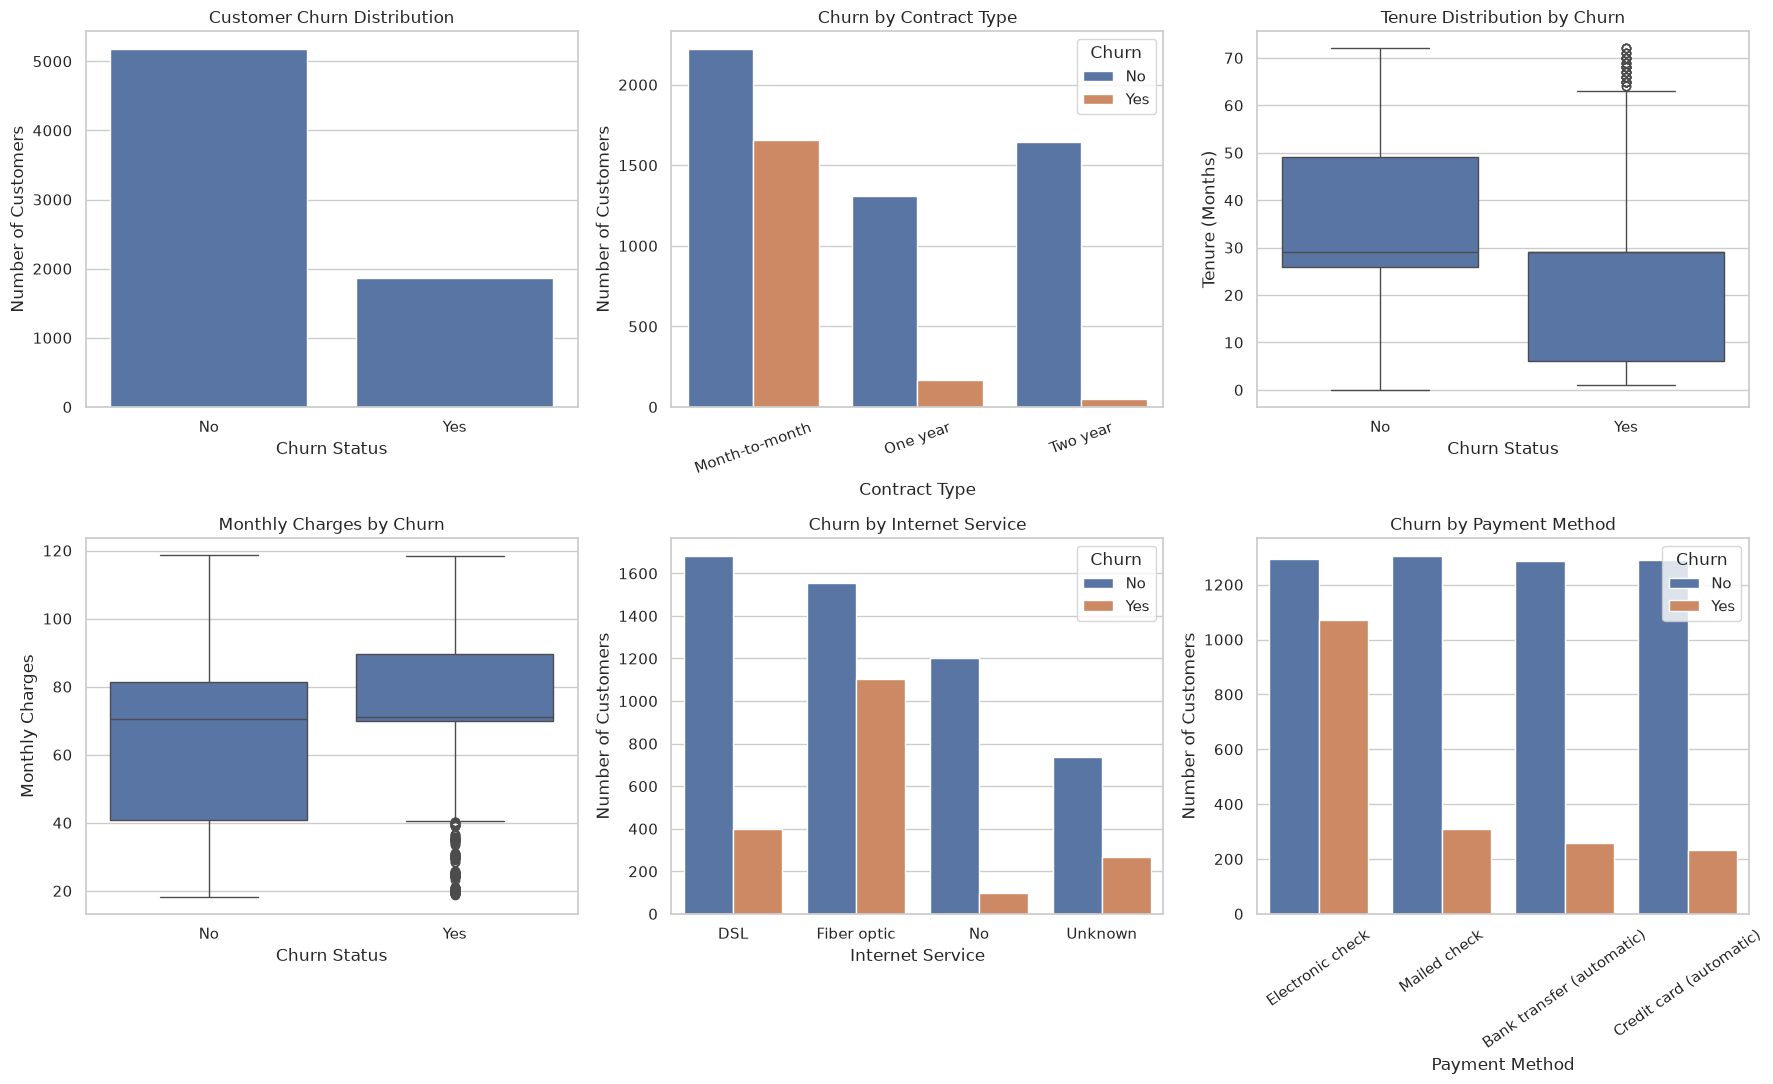

In [22]:
# Set the visualisation style

sns.set_theme(style="whitegrid")

# Create a figure with 6 visualisations

fig, axes = plt.subplots(2, 3, figsize=(18, 11))


# 1. Churn Distribution

sns.countplot(
    data=df_clean,
    x="Churn",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Customer Churn Distribution")
axes[0, 0].set_xlabel("Churn Status")
axes[0, 0].set_ylabel("Number of Customers")


# 2. Churn by Contract Type

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Churn by Contract Type")
axes[0, 1].set_xlabel("Contract Type")
axes[0, 1].set_ylabel("Number of Customers")
axes[0, 1].tick_params(axis="x", rotation=20)


# 3. Tenure Distribution by Churn

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure",
    ax=axes[0, 2]
)

axes[0, 2].set_title("Tenure Distribution by Churn")
axes[0, 2].set_xlabel("Churn Status")
axes[0, 2].set_ylabel("Tenure (Months)")


# 4. Monthly Charges by Churn

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Monthly Charges by Churn")
axes[1, 0].set_xlabel("Churn Status")
axes[1, 0].set_ylabel("Monthly Charges")


# 5. Churn by Internet Service

sns.countplot(
    data=df_clean,
    x="InternetService",
    hue="Churn",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Churn by Internet Service")
axes[1, 1].set_xlabel("Internet Service")
axes[1, 1].set_ylabel("Number of Customers")


# 6. Churn by Payment Method

sns.countplot(
    data=df_clean,
    x="PaymentMethod",
    hue="Churn",
    ax=axes[1, 2]
)

axes[1, 2].set_title("Churn by Payment Method")
axes[1, 2].set_xlabel("Payment Method")
axes[1, 2].set_ylabel("Number of Customers")
axes[1, 2].tick_params(axis="x", rotation=35)


plt.tight_layout()
plt.show()

In [23]:
# Churn counts and percentages

churn_summary = df_clean["Churn"].value_counts()

churn_percentage = (
    df_clean["Churn"].value_counts(normalize=True) * 100
).round(2)

churn_table = pd.DataFrame({
    "Customer Count": churn_summary,
    "Percentage": churn_percentage
})

churn_table

,Customer Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [24]:
# Average numerical features by churn status

numerical_eda = df_clean.groupby("Churn")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

numerical_eda

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,34.48,63.38,2552.88
Yes,22.44,73.57,1531.80


In [25]:
# Churn rate by contract type

contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [26]:
# Churn rate by internet service

internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,80.74,19.26
Fiber optic,58.50,41.50
No,92.39,7.61
Unknown,73.50,26.50


# 7. Statistical Analysis

Statistical analysis is performed on the key numerical variables to understand their central tendency and dispersion.

The analysis includes:

- Mean and median to measure central tendency.
- Standard deviation, minimum and maximum values to measure dispersion.
- Quartiles and Interquartile Range (IQR) to identify potential outliers.

In [27]:
# Statistical summary of key numerical variables

statistical_summary = df_clean[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].describe().T

statistical_summary

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,31.287662,19.753692,0.00,19.000,29.000,41.00,72.0
MonthlyCharges,7043.0,66.084751,26.804520,18.25,49.450,70.550,84.85,118.6
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.8


In [28]:
# IQR and outlier analysis

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

iqr_results = []

for column in numerical_features:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    iqr_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(
            len(outliers) / len(df_clean) * 100, 2
        )
    })

iqr_summary = pd.DataFrame(iqr_results)

iqr_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,tenure,19.000,41.00,22.000,-14.0000,74.0000,0,0.0
1,MonthlyCharges,49.450,84.85,35.400,-3.6500,137.9500,0,0.0
2,TotalCharges,402.225,3786.60,3384.375,-4674.3375,8863.1625,0,0.0


In [29]:
# Compare mean and median

central_tendency = df_clean[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].agg(["mean", "median"]).T

central_tendency

,mean,median
tenure,31.287662,29.000
MonthlyCharges,66.084751,70.550
TotalCharges,2281.916928,1397.475


# 8. Data Preprocessing

Machine learning algorithms require numerical input. The cleaned dataset contains both numerical and categorical variables, so categorical features must be encoded before model training.

The `customerID` column is excluded because it is an identifier and does not provide meaningful predictive information.

The `Churn` column is separated as the target variable.

Categorical predictor variables are converted into numerical features using one-hot encoding.

In [30]:
# Separate features and target

X = df_clean.drop(columns=["Churn", "customerID"])
y = df_clean["Churn"].map({"No": 0, "Yes": 1})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 19)
Target shape: (7043,)


In [31]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# 9. Train-Test Split

The dataset is divided into training and testing subsets. The training data is used to learn the relationships between customer characteristics and churn, while the test data is reserved for evaluating the model on unseen customers.

A stratified split is used to preserve the proportion of churned and non-churned customers in both datasets.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

Training samples: 5634
Testing samples: 1409

Training churn rate: 26.54 %
Testing churn rate: 26.54 %


# 10. Logistic Regression Model

Logistic Regression is used as the primary classification model because the target variable, `Churn`, has two possible outcomes: customers who churn and customers who do not churn.

The model estimates the probability that a customer will churn based on the available customer characteristics.

In [34]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


# 11. Model Evaluation

The Logistic Regression model is evaluated on the unseen test dataset using accuracy, precision, recall, F1-score and a confusion matrix.

These metrics provide a more complete view of model performance than accuracy alone, particularly because identifying customers who are likely to churn is an important business objective.

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Generate predictions

y_pred = logistic_model.predict(X_test)

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
-----------------------------------
Accuracy : 0.7906
Precision: 0.6295
Recall   : 0.5134
F1-Score : 0.5655

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Confusion Matrix:
[[922 113]
 [182 192]]


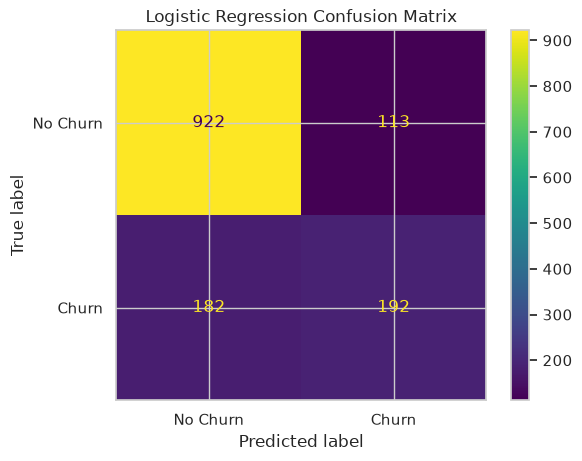

In [36]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 11.1 Model Performance Interpretation

The Logistic Regression model achieved an accuracy of approximately 79.06% on the test dataset.

For the churn class, the model achieved a precision of 62.95%, meaning that when the model predicts a customer will churn, the prediction is correct in a substantial proportion of cases.

The recall for churn was 51.34%. This indicates that the model successfully identifies approximately half of the customers who actually churned. The remaining churned customers were classified as non-churned.

The F1-score for the churn class was 56.55%, showing a moderate balance between precision and recall.

From a business perspective, the model provides a useful baseline for identifying customers who may require retention attention. However, because missing an actual churner can result in a lost retention opportunity, improving churn recall would be an important area for future model improvement.

# 12. Linear Regression Extension

To demonstrate the difference between classification and regression, a Linear Regression model is developed to predict the continuous variable `TotalCharges`.

Unlike Logistic Regression, which predicts a categorical outcome such as customer churn, Linear Regression predicts a continuous numerical value.

In this extension, the model estimates a customer's total charges based on their tenure, monthly charges, services, contract type and other customer characteristics.

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create regression features and target

X_reg = df_clean.drop(columns=["TotalCharges", "customerID"])
y_reg = df_clean["TotalCharges"]

# Identify numerical and categorical features

reg_numerical_features = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical_features = X_reg.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:", reg_numerical_features)
print("Categorical features:", reg_categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [41]:
# Split regression data

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_reg_train))
print("Testing samples:", len(X_reg_test))

Training samples: 5634
Testing samples: 1409


In [42]:
# Create regression preprocessing pipeline

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            reg_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            reg_categorical_features
        )
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Train the model

linear_model.fit(X_reg_train, y_reg_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [43]:
# Generate predictions

y_reg_pred = linear_model.predict(X_reg_test)

# Evaluate the model

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE : 1118.64
MSE : 2422185.89
RMSE: 1556.34
R²  : 0.5341


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


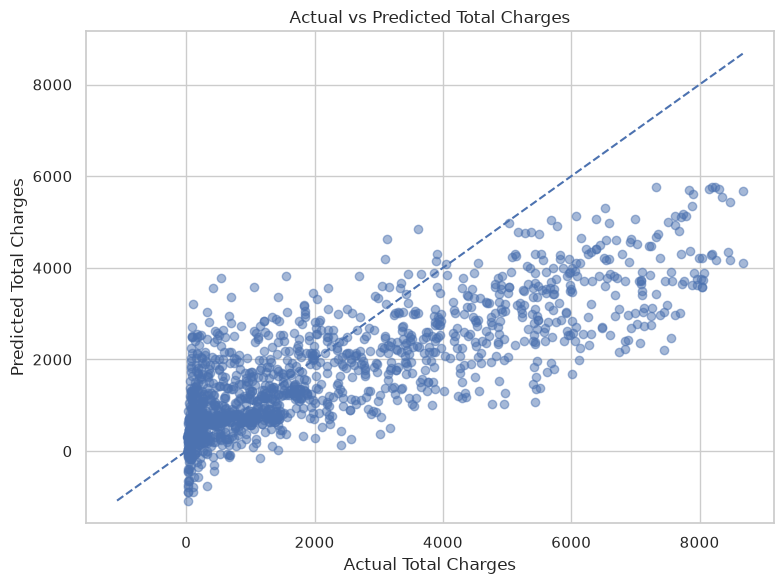

In [44]:
# Actual vs predicted TotalCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    y_reg_test,
    y_reg_pred,
    alpha=0.5
)

# Perfect prediction reference line

min_value = min(y_reg_test.min(), y_reg_pred.min())
max_value = max(y_reg_test.max(), y_reg_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Total Charges")
plt.ylabel("Predicted Total Charges")
plt.title("Actual vs Predicted Total Charges")

plt.tight_layout()
plt.show()

## 12.1 Linear Regression Interpretation

The Linear Regression model achieved an R² score of 0.5341, indicating that approximately 53.4% of the variation in customer TotalCharges is explained by the features included in the model.

The model achieved a Mean Absolute Error (MAE) of 1118.64 and a Root Mean Squared Error (RMSE) of 1556.34. These results indicate that prediction errors remain substantial, but the model captures a meaningful portion of the relationship between customer characteristics and total charges.

This regression task differs from the churn classification task because Linear Regression predicts a continuous numerical value, whereas Logistic Regression predicts a categorical outcome.

# 13. Feature Interpretation

The coefficients of the Logistic Regression model are examined to identify which customer characteristics have the strongest association with the predicted probability of churn.

Positive coefficients indicate an increased tendency toward the churn class, while negative coefficients indicate a decreased tendency toward churn, with other model features held constant.

In [45]:
# Extract feature names from the trained preprocessing pipeline

preprocessor_fitted = logistic_model.named_steps["preprocessor"]
classifier = logistic_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()

coefficients = classifier.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient magnitude

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Display strongest features

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
29,cat__Contract_Two year,-1.611208,1.611208
12,cat__InternetService_Fiber optic,0.912529,0.912529
28,cat__Contract_One year,-0.856997,0.856997
3,num__TotalCharges,-0.568502,0.568502
13,cat__InternetService_No,0.537271,0.537271
32,cat__PaymentMethod_Electronic check,0.453298,0.453298
9,cat__PhoneService_Yes,-0.439430,0.439430
16,cat__OnlineSecurity_Yes,-0.434489,0.434489
27,cat__StreamingMovies_Yes,0.379827,0.379827
30,cat__PaperlessBilling_Yes,0.370309,0.370309


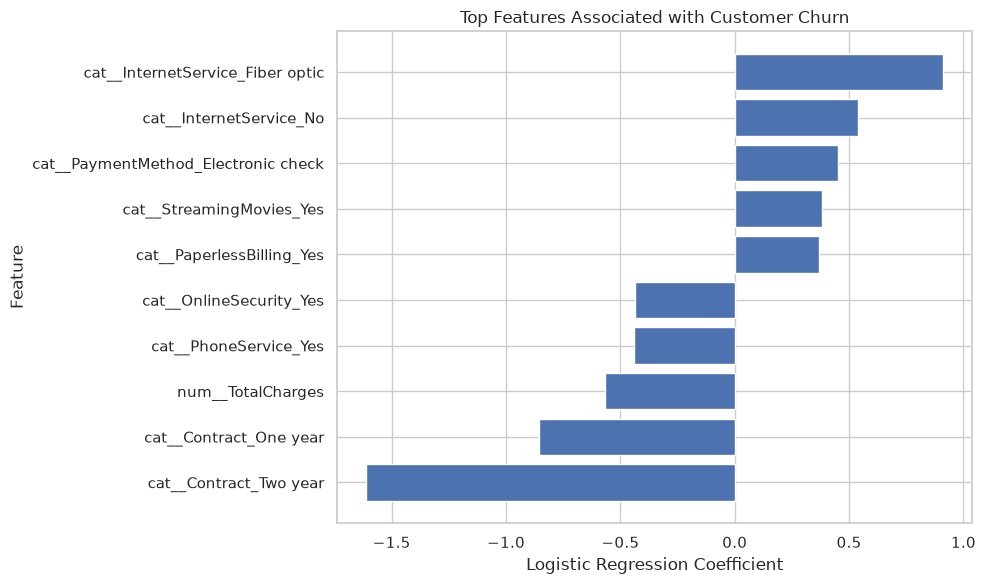

In [46]:
# Visualise the 10 strongest Logistic Regression coefficients

top_features = feature_importance.head(10).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated with Customer Churn")

plt.tight_layout()
plt.show()

## 13.1 Feature Interpretation

The Logistic Regression coefficients provide insight into which customer characteristics are most strongly associated with churn predictions.

The strongest positive coefficient was associated with Fiber optic internet service, suggesting a higher predicted tendency toward churn compared with the reference category. Electronic check payment and paperless billing also showed positive associations with churn.

Contract type showed some of the strongest negative coefficients. One-year and especially two-year contracts were associated with a substantially lower predicted tendency toward churn compared with the reference contract category.

Online Security and Phone Service also showed negative associations with churn.

These coefficients represent associations within the fitted model and should not be interpreted as proof of causation.

# 14. Client Risk Insights

The trained Logistic Regression model produces a churn probability for each customer in the test dataset. These probabilities are converted into practical risk categories to help the client prioritise retention efforts.

Risk categories are defined as:

- Low Risk: churn probability below 30%
- Medium Risk: churn probability from 30% to below 60%
- High Risk: churn probability of 60% or higher

In [47]:
# Generate churn probabilities

churn_probability = logistic_model.predict_proba(X_test)[:, 1]

risk_insights = X_test.copy()

risk_insights["Actual_Churn"] = y_test.values
risk_insights["Churn_Probability"] = churn_probability

# Assign risk categories

risk_insights["Risk_Category"] = pd.cut(
    risk_insights["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Display risk distribution

risk_distribution = (
    risk_insights["Risk_Category"]
    .value_counts()
    .sort_index()
)

risk_distribution

Risk_Category
Low Risk       862
Medium Risk    348
High Risk      199
Name: count, dtype: int64

In [48]:
# Risk category percentages

risk_percentage = (
    risk_insights["Risk_Category"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

risk_summary = pd.DataFrame({
    "Customer Count": risk_distribution,
    "Percentage": risk_percentage
})

risk_summary

,Customer Count,Percentage
Risk_Category,,
Low Risk,862,61.18
Medium Risk,348,24.70
High Risk,199,14.12


In [49]:
# Churn rate within each risk category

risk_churn_rate = (
    risk_insights.groupby("Risk_Category", observed=True)["Actual_Churn"]
    .mean() * 100
)

risk_churn_rate.round(2)

Risk_Category
Low Risk       11.14
Medium Risk    39.94
High Risk      69.85
Name: Actual_Churn, dtype: float64

# 15. Business Recommendations

Based on the exploratory analysis, Logistic Regression results, feature coefficients, and customer risk segmentation, the following business recommendations are proposed.

### 1. Prioritise High-Risk Customers

High-risk customers should receive the highest priority for retention activities. This group represents 14.12% of the test customers and has an observed churn rate of 69.85%.

The company can consider targeted retention offers, proactive customer support, contract incentives, or personalised communication for this segment.

### 2. Focus on Month-to-Month Customers

Month-to-month contracts show substantially higher churn compared with one-year and two-year contracts. The company should consider incentives that encourage customers to move toward longer-term contracts.

Possible approaches include discounts, loyalty benefits, or additional services for customers willing to commit to longer contracts.

### 3. Investigate Fiber Optic Customer Churn

Fiber optic customers show a strong positive association with churn in the Logistic Regression model. The company should investigate service quality, pricing, customer support, and competitor offerings for this customer segment.

### 4. Target Electronic Check Customers

Electronic check payment has a positive association with churn in the model. Customers using this payment method could be included in targeted retention campaigns and encouraged to adopt convenient automatic payment methods where appropriate.

### 5. Strengthen Online Security and Technical Support

Online Security and Tech Support show negative associations with churn. Promoting these services and improving customer awareness of their benefits may support customer retention.

### 6. Use Risk-Based Retention

Rather than applying the same retention strategy to every customer, the company should prioritise customers according to predicted churn risk.

High-risk customers should receive the most intensive intervention, medium-risk customers should receive preventive engagement, and low-risk customers can be maintained through regular service and loyalty activities.

# 16. Conclusion

This project developed an end-to-end customer churn prediction and business insight system using the Telco Customer Churn dataset.

The analysis included data loading, data quality assessment, missing-value treatment, exploratory data analysis, statistical analysis, feature preprocessing, Logistic Regression classification, Linear Regression, and customer risk segmentation.

The Logistic Regression model achieved an accuracy of 79.06%, with a churn recall of 51.34% and an F1-score of 56.55%. The model provides a useful baseline for identifying customers who may be at risk of churn.

The risk segmentation further demonstrated practical value. The observed churn rate increased from 11.14% for low-risk customers to 39.94% for medium-risk customers and 69.85% for high-risk customers.

The analysis indicates that contract type, internet service, payment method, and additional customer services are among the important factors associated with churn. These findings can support targeted retention strategies and help the company allocate retention resources more effectively.

Overall, the project demonstrates how data analysis and machine learning can be combined to transform customer data into actionable business insights.

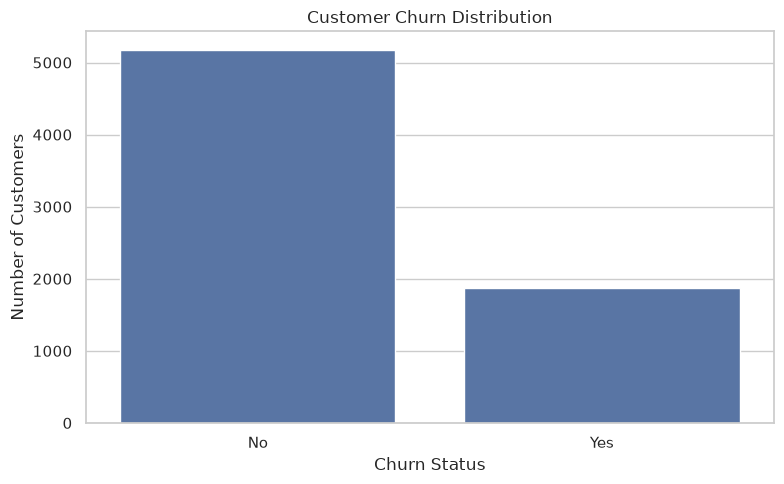

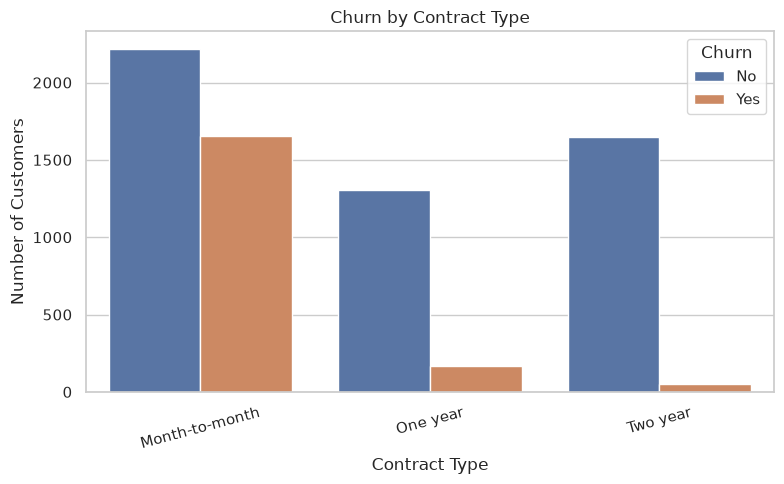

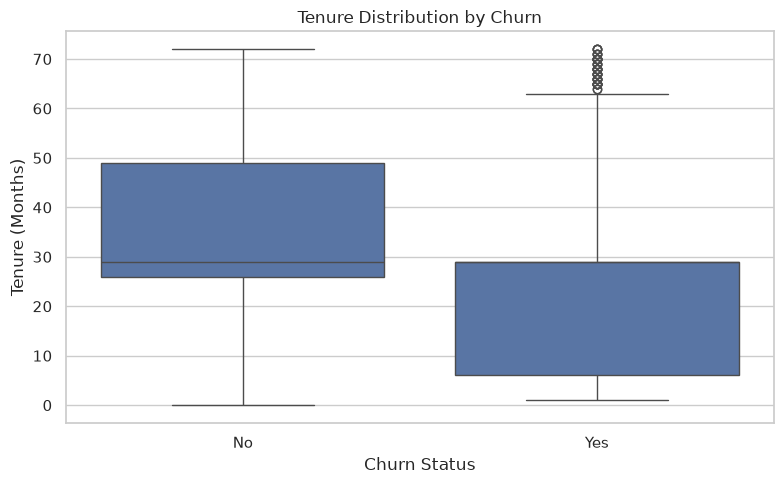

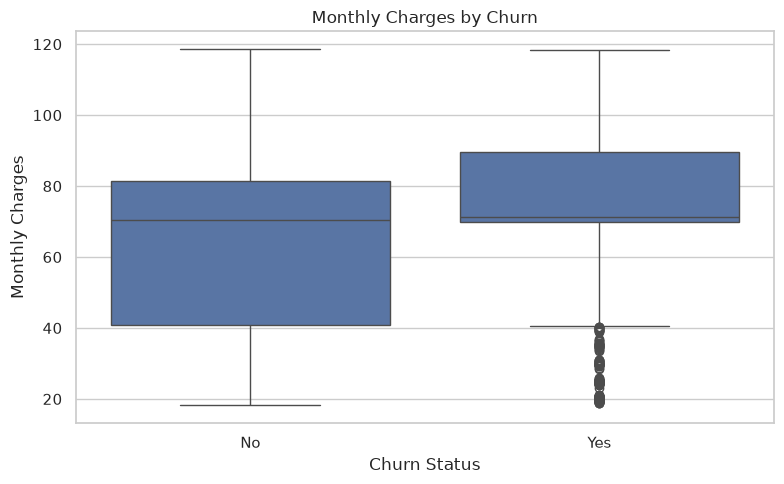

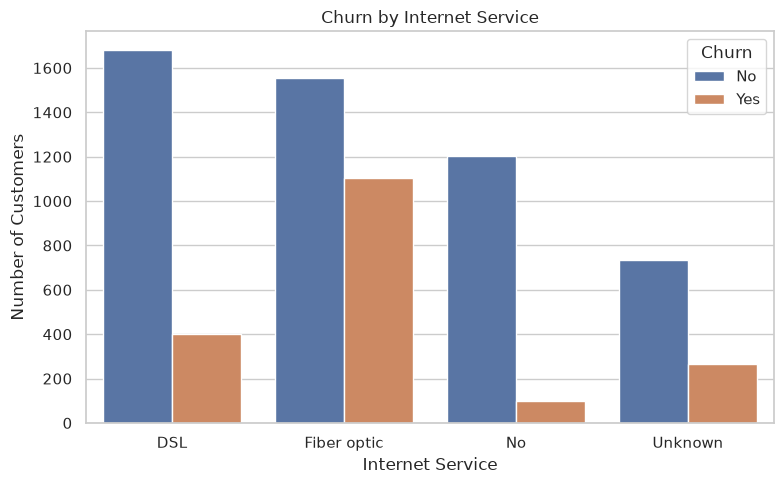

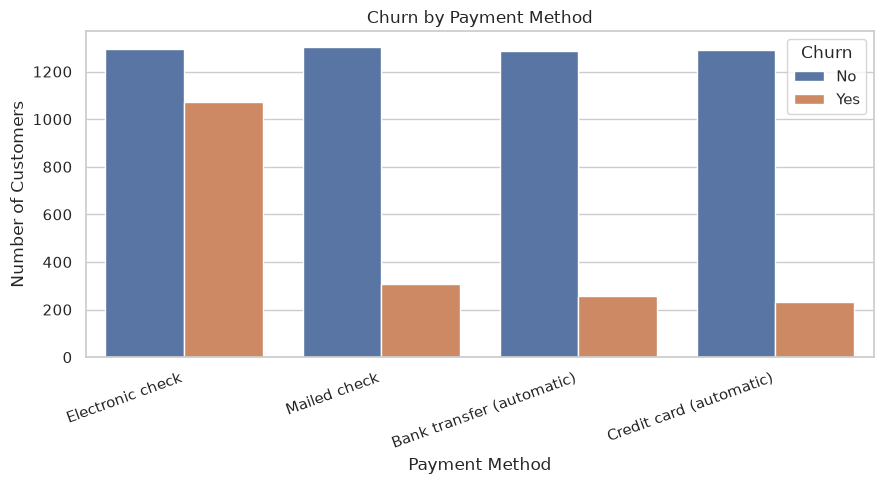

All visualizations saved successfully!


In [50]:
# Save final project visualizations

import os

os.makedirs("../visualizations", exist_ok=True)

# 1. Customer Churn Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../visualizations/01_customer_churn_distribution.png", dpi=300)
plt.show()


# 2. Churn by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/02_churn_by_contract.png", dpi=300)
plt.show()


# 3. Tenure Distribution by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.savefig("../visualizations/03_tenure_by_churn.png", dpi=300)
plt.show()


# 4. Monthly Charges by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig("../visualizations/04_monthly_charges_by_churn.png", dpi=300)
plt.show()


# 5. Churn by Internet Service
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../visualizations/05_churn_by_internet_service.png", dpi=300)
plt.show()


# 6. Churn by Payment Method
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../visualizations/06_churn_by_payment_method.png", dpi=300)
plt.show()

print("All visualizations saved successfully!")